# Macro-Based Survey Expectations Pipeline

**Goal:** Predict median survey expectations for four series using Shiller macro
features only — no text embeddings. Evaluate via walk-forward expanding-window
cross-validation, then extrapolate fitted models backward to 1920.

**Four target series:**
- `dividend_growth`  — Expected 1-year log dividend growth (quarterly survey)
- `earnings_growth`  — Expected 1-year log earnings growth (quarterly survey)
- `returns_1yr`      — Expected 1-year S&P 500 return
- `returns_10yr`     — Expected 10-year S&P 500 annualised return

**Design decisions:**
- FinBERT embeddings dropped entirely — news added zero incremental R² over macro
- Separate model class per series: Ridge for earnings/returns, mean-reversion
  model for dividends (survey moves opposite to realised — consistent with
  board-level payout targeting)
- Regime-aware evaluation: rolling RMSE plotted across regimes
- Extrapolation back to 1920 using Shiller features only (available from 1871)


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import pickle, json
from datetime import datetime

from sklearn.linear_model import RidgeCV, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from sklearn.model_selection import LeaveOneOut

np.random.seed(42)
print("Imports OK")


Imports OK


In [6]:
# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR    = Path("./")
DATA_DIR    = BASE_DIR / "data"
OUTPUT_DIR  = BASE_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SHILLER_XLS          = DATA_DIR / "ie_data.xls"
DIVIDEND_SURVEY_XLS  = DATA_DIR / "Dividend_growth_expectations.xlsx"
EARNINGS_SURVEY_XLS  = DATA_DIR / "Earnings_growth_expectations.xlsx"
RETURNS_XLS          = DATA_DIR / "return_expectations_quarterly.xlsx"

# ── Walk-forward settings ──────────────────────────────────────────────────────
# Minimum calibration waves before first out-of-sample prediction.
# Dividend series is short (~49 waves) so MIN_TRAIN_WAVES is lower.
MIN_TRAIN_WAVES = {
    "dividend_growth": 25,
    "earnings_growth": 40,
    "returns_1yr":     30,
    "returns_10yr":    30,
}

# ── Shiller feature set ────────────────────────────────────────────────────────
# All point-in-time at wave closing date — no look-ahead.
# Available continuously from 1871 (cape_inv from 1881).
# ── Per-series feature sets (selected by walk-forward parsimonious search) ─────
# Fewer features → higher stability (subsample r), better or equal WF R².
# Shiller loader still builds all features; these dicts control what each
# model sees at training time.
SERIES_FEATURES = {
    "dividend_growth": [          # full-18 wins; all features needed for div
        "dp_ratio","ep_ratio","cape_inv","gs10","infl_yoy","real_price_gr",
        "div_gr_yoy","earn_gr_yoy","div_gr_lag4","div_gr_lag8",
        "earn_gr_lag4","earn_gr_lag8","earn_gr_chg","div_gr_chg",
        "trailing_1yr_ret","trailing_3yr_ret","dp_dev","earn_dev",
    ],
    "earnings_growth": [          # 3-feature parsimonious: R²=0.685, stab=0.965
        "ep_ratio",               #   earnings yield — primary signal
        "cape_inv",               #   cyclically-adjusted earnings yield
        "real_price_gr",          #   market momentum
    ],
    "returns_1yr": [              # 3-feature parsimonious: R²=-0.070, stab=0.886
        "gs10",                   #   10y Treasury — dominant signal
        "dp_ratio",               #   dividend yield
        "infl_yoy",               #   inflation regime
    ],
    "returns_10yr": [             # 3-feature parsimonious: R²=+0.137, stab=0.880
        "gs10",                   #   10y Treasury — dominant signal
        "ep_ratio",               #   earnings yield
        "dp_ratio",               #   dividend yield
    ],
}

# Union of all features — used by load_shiller() to ensure all cols are built
SHILLER_FEATURES = list({f for feats in SERIES_FEATURES.values() for f in feats})

# ── Sentiment feature (LM net sentiment from WSJ headlines) ───────────────────
# USE_SENTIMENT = False runs macro-only baseline for clean incremental R2 comparison
USE_SENTIMENT    = True
WSJ_PARQUET      = DATA_DIR / "wsj_headlines.parquet"   # TODO: confirm exact filename
LM_POSITIVE_PATH = DATA_DIR / "LM_positive.txt"         # Loughran-McDonald word lists
LM_NEGATIVE_PATH = DATA_DIR / "LM_negative.txt"         # download from LM website if needed

# ── Ridge alpha grid ───────────────────────────────────────────────────────────
ALPHA_GRID = np.logspace(-3, 4, 50)



# ── Extrapolation range ────────────────────────────────────────────────────────
EXTRAP_START = "1920-01-01"
EXTRAP_END   = "1970-01-01"   # pre-survey period endpoint

print("Config OK")
print(f"Output directory: {OUTPUT_DIR}")


Config OK
Output directory: output


## 1. Load Shiller Macro Features

`ie_data.xls` provides monthly S&P 500 price, dividends, earnings, CPI, and
10-year Treasury rate back to 1871. All features are constructed point-in-time
with no look-ahead.

**Extended feature set vs prior pipeline:**
- Added `trailing_1yr_ret` and `trailing_3yr_ret` — motivated by Greenwood &
  Shleifer (2014): survey return expectations are largely extrapolative from
  recent realised returns
- Added `dp_dev` and `earn_dev` — deviation from rolling mean; captures the
  mean-reversion signal that explains why dividend survey expectations move
  *opposite* to realised dividend growth (boards target long-run payout ratios)


In [7]:
def load_shiller(path=SHILLER_XLS):
    """
    Load Shiller ie_data.xls and construct monthly macro feature table.
    Returns DataFrame indexed by month-start date with columns = SHILLER_FEATURES.
    """
    raw = pd.read_excel(path, sheet_name="Data", header=7)
    raw.columns = raw.columns.str.strip()

    # Date: Shiller stores as float e.g. 1871.01 (year.month)
    # pd.to_datetime with format="%Y.%m" fails on floats — parse manually
    raw = raw.dropna(subset=[raw.columns[0]])
    def _parse_shiller_date(f):
        year  = int(f)
        month = round((f - year) * 100)
        month = max(1, min(12, month if month > 0 else 1))
        return pd.Timestamp(year=year, month=month, day=1)
    raw["date"] = raw.iloc[:, 0].apply(_parse_shiller_date)
    raw = raw.set_index("date").sort_index()

    # Rename core columns by name (robust to column reordering)
    df = pd.DataFrame(index=raw.index)
    df["price"]    = pd.to_numeric(raw["P"],         errors="coerce")
    df["dividend"] = pd.to_numeric(raw["D"],         errors="coerce")
    df["earnings"] = pd.to_numeric(raw["E"],         errors="coerce")
    df["cpi"]      = pd.to_numeric(raw["CPI"],       errors="coerce")
    df["gs10"]     = pd.to_numeric(raw["Rate GS10"], errors="coerce")
    cape_cols      = [c for c in raw.columns if "cape" in str(c).lower()]
    df["cape"]     = pd.to_numeric(raw[cape_cols[0]], errors="coerce") if cape_cols else np.nan

    # ── Derived features ───────────────────────────────────────────────────────
    # Yields
    df["dp_ratio"]  = df["dividend"] / df["price"]
    df["ep_ratio"]  = df["earnings"] / df["price"]
    df["cape_inv"]  = 1.0 / df["cape"].replace(0, np.nan)

    # Inflation
    df["infl_yoy"]  = df["cpi"].pct_change(12)

    # Real price growth
    df["real_price"] = df["price"] / df["cpi"]
    df["real_price_gr"] = df["real_price"].pct_change(12)

    # Realised growth rates (AR1 proxies)
    df["div_gr_yoy"]  = df["dividend"].pct_change(12)
    df["earn_gr_yoy"] = df["earnings"].pct_change(12)

    # Trailing total returns (price + dividend yield approximation)
    df["monthly_ret"]     = df["price"].pct_change() + df["dp_ratio"] / 12
    df["trailing_1yr_ret"] = (1 + df["monthly_ret"]).rolling(12).apply(np.prod, raw=True) - 1
    df["trailing_3yr_ret"] = (1 + df["monthly_ret"]).rolling(36).apply(np.prod, raw=True) - 1

    # Mean-reversion deviation features
    df["dp_dev"]   = df["dp_ratio"]   - df["dp_ratio"].rolling(120, min_periods=60).mean()
    df["earn_dev"] = df["earn_gr_yoy"] - df["earn_gr_yoy"].rolling(120, min_periods=60).mean()

    # Explicit lags (4 and 8 quarters = 12 and 24 months)
    df["div_gr_lag4"]  = df["div_gr_yoy"].shift(3)    # ~1 quarter lag (monthly data)
    df["div_gr_lag8"]  = df["div_gr_yoy"].shift(6)    # ~2 quarter lag
    df["earn_gr_lag4"] = df["earn_gr_yoy"].shift(3)
    df["earn_gr_lag8"] = df["earn_gr_yoy"].shift(6)

    # Revision momentum: is the trend improving or deteriorating?
    df["earn_gr_chg"] = df["earn_gr_yoy"].diff(3)     # change over ~1 quarter
    df["div_gr_chg"]  = df["div_gr_yoy"].diff(3)

    # ── Clip earnings outliers ─────────────────────────────────────────────────
    # COVID snap-back creates earn_gr_yoy = 7.9 (790%) which dominates RMSE and
    # destabilises Ridge coefficients. Clip all earnings-derived features at ±100%.
    earn_cols = ["earn_gr_yoy", "earn_gr_lag4", "earn_gr_lag8",
                 "earn_gr_chg", "earn_dev"]
    for col in earn_cols:
        if col in df.columns:
            df[col] = df[col].clip(-1.0, 1.0)

    # Forward-fill then drop remaining NaN rows
    df = df.ffill().dropna(subset=SHILLER_FEATURES)

    return df[SHILLER_FEATURES]


shiller_df = load_shiller()
print(f"Shiller features loaded: {shiller_df.index[0].date()} → {shiller_df.index[-1].date()}")
print(f"Shape: {shiller_df.shape}")
shiller_df.tail(3)


Shiller features loaded: 1876-12-01 → 2026-05-01
Shape: (1794, 18)


,dp_ratio,ep_ratio,cape_inv,gs10,infl_yoy,real_price_gr,div_gr_yoy,earn_gr_yoy,div_gr_lag4,div_gr_lag8,earn_gr_lag4,earn_gr_lag8,earn_gr_chg,div_gr_chg,trailing_1yr_ret,trailing_3yr_ret,dp_dev,earn_dev
date,,,,,,,,,,,,,,,,,,
2026-03-01,3.284462,0.039471,0.000494,330.213,0.291741,-0.225465,0.101964,0.056301,0.140098,0.169898,0.062643,0.071005,-0.006343,-0.038134,15.217044,1593.411854,1.359638,-0.007158
2026-04-01,3.433796,0.039471,0.000494,331.927,0.278785,-0.217622,0.223967,0.050229,0.158810,0.171271,0.058457,0.069210,-0.008228,0.065157,15.903681,1761.524137,1.488714,-0.013021
2026-05-01,3.582942,0.039471,0.000493,332.784,0.267399,-0.210597,0.351937,0.044719,0.023474,0.136759,0.012601,0.064804,0.032118,0.328463,16.978235,1955.599182,1.616582,-0.018305


## 1b. Load LM Sentiment from WSJ Headlines

Constructs a **single scalar sentiment feature** per month using the
Loughran-McDonald (2011) financial dictionary — the standard in finance NLP.

**Net sentiment** = (positive words − negative words) / total words per article,
then averaged across all articles in the month.

This is distinct from FinBERT in two important ways:
- No neural network, no lookahead contamination from pretraining
- Purely lexical — each word is independently scored; no context encoding

The feature is merged into the Shiller monthly table so the alignment function
works identically whether `USE_SENTIMENT = True` or `False`.

**Incremental R² test:** The pipeline reports results both with and without
this feature so the marginal contribution of sentiment is cleanly identified.


In [8]:
def load_lm_wordlists(pos_path=LM_POSITIVE_PATH, neg_path=LM_NEGATIVE_PATH):
    """Load Loughran-McDonald positive and negative word lists."""
    try:
        with open(pos_path) as f:
            positive = set(w.strip().lower() for w in f if w.strip())
        with open(neg_path) as f:
            negative = set(w.strip().lower() for w in f if w.strip())
        print(f"LM wordlists loaded: {len(positive)} positive, {len(negative)} negative")
        return positive, negative
    except FileNotFoundError as e:
        print(f"WARNING: LM wordlist not found — {e}")
        print("Download from: https://sraf.nd.edu/loughranmcdonald-master-dictionary/")
        return set(), set()


def compute_lm_sentiment(wsj_parquet=WSJ_PARQUET, pos_words=None, neg_words=None):
    """
    Compute monthly LM net sentiment from WSJ headlines.

    Returns a monthly Series indexed by month-start date with values in [-1, 1].
    Months with no articles return NaN (forward-filled downstream).

    net_sentiment_article = (n_pos - n_neg) / max(n_total, 1)
    monthly_sentiment     = mean(net_sentiment_article) across articles in month
    """
    if pos_words is None or len(pos_words) == 0:
        print("No LM wordlists — returning zero sentiment series")
        return pd.Series(dtype=float, name="lm_sentiment")

    print(f"Loading WSJ headlines from {wsj_parquet}...")
    news = pd.read_parquet(wsj_parquet, columns=["date", "headline"])
    news["date"] = pd.to_datetime(news["date"], errors="coerce")
    news = news.dropna(subset=["date", "headline"])
    news = news[news["headline"].str.strip().str.len() > 0]
    print(f"  Loaded {len(news):,} headlines spanning "
          f"{news['date'].min().date()} → {news['date'].max().date()}")

    # Score each headline
    def score(text):
        words = str(text).lower().split()
        if not words:
            return 0.0
        n_pos = sum(1 for w in words if w in pos_words)
        n_neg = sum(1 for w in words if w in neg_words)
        return (n_pos - n_neg) / len(words)

    print("  Scoring headlines (this may take a moment)...")
    news["sentiment"] = news["headline"].apply(score)

    # Aggregate to monthly mean
    news["month"] = news["date"].dt.to_period("M").dt.to_timestamp()
    monthly = news.groupby("month")["sentiment"].mean().rename("lm_sentiment")
    print(f"  Monthly sentiment computed: {len(monthly)} months, "
          f"mean={monthly.mean():.4f}, std={monthly.std():.4f}")
    return monthly


# ── Run sentiment loading ──────────────────────────────────────────────────────
if USE_SENTIMENT:
    lm_pos, lm_neg = load_lm_wordlists()
    lm_sentiment   = compute_lm_sentiment(pos_words=lm_pos, neg_words=lm_neg)

    # Merge into shiller_df
    shiller_df = shiller_df.join(
        lm_sentiment.reindex(shiller_df.index).rename("lm_sentiment"),
        how="left"
    )
    # Forward-fill gaps (months with no WSJ coverage)
    shiller_df["lm_sentiment"] = shiller_df["lm_sentiment"].ffill().fillna(0.0)

    # Add to feature list
    if "lm_sentiment" not in SHILLER_FEATURES:
        SHILLER_FEATURES.append("lm_sentiment")

    print(f"\nSentiment feature added. Total features: {len(SHILLER_FEATURES)}")
    print(f"NaN months after ffill: {shiller_df['lm_sentiment'].isna().sum()}")
else:
    print("USE_SENTIMENT = False — running macro-only baseline")
    print(f"Total features: {len(SHILLER_FEATURES)}")

print(f"\nFull feature list ({len(SHILLER_FEATURES)}):")
for i, f in enumerate(SHILLER_FEATURES):
    print(f"  {i+1:2d}. {f}")


Download from: https://sraf.nd.edu/loughranmcdonald-master-dictionary/
No LM wordlists — returning zero sentiment series

Sentiment feature added. Total features: 19
NaN months after ffill: 0

Full feature list (19):
   1. dp_ratio
   2. ep_ratio
   3. cape_inv
   4. gs10
   5. infl_yoy
   6. real_price_gr
   7. div_gr_yoy
   8. earn_gr_yoy
   9. div_gr_lag4
  10. div_gr_lag8
  11. earn_gr_lag4
  12. earn_gr_lag8
  13. earn_gr_chg
  14. div_gr_chg
  15. trailing_1yr_ret
  16. trailing_3yr_ret
  17. dp_dev
  18. earn_dev
  19. lm_sentiment


## 2. Load Survey Data

Four target series. Dividend and earnings are from quarterly survey Excel files.
Returns series paths should be confirmed — update `RETURNS_1YR_CSV` /
`RETURNS_10YR_CSV` in config if format differs.


In [9]:
def load_dividend_survey(path=DIVIDEND_SURVEY_XLS):
    df = pd.read_excel(path)
    df["wave_date"] = pd.to_datetime(
        df["Year"].astype(str) + "Q" + df["Quarter"].astype(str)
    )
    df["median_forecast"] = pd.to_numeric(
        df["Expected one-year log dividend growth"], errors="coerce"
    )
    return (df[["wave_date", "median_forecast"]]
            .dropna().sort_values("wave_date").reset_index(drop=True))


def load_earnings_survey(path=EARNINGS_SURVEY_XLS):
    raw = pd.read_excel(path, header=None)
    # Multi-row merged header — use positional access
    # Row 2 onward is data; col 0 = year, col 1 = quarter, col 2 = expected growth
    data = raw.iloc[2:].copy()
    data.columns = range(data.shape[1])
    df = pd.DataFrame()
    df["wave_date"] = pd.to_datetime(
        data.iloc[:, 0].astype(str) + "Q" + data.iloc[:, 1].astype(str),
        errors="coerce"
    )
    df["median_forecast"] = pd.to_numeric(data.iloc[:, 2], errors="coerce")
    return df.dropna().sort_values("wave_date").reset_index(drop=True)


def load_returns_survey(path=RETURNS_XLS):
    """
    Load both returns series from return_expectations_quarterly.xlsx.
    Actual columns: year, qtr, sp_1yr_median, sp_10yr_median (plus others).
    Wave date constructed from year + qtr.
    Returns are in PERCENTAGE POINTS (e.g. 8.0 = 8%).
    """
    raw = pd.read_excel(path, header=0)
    df  = pd.DataFrame()
    df["wave_date"]   = pd.to_datetime(
        raw["year"].astype(str) + "Q" + raw["qtr"].astype(str)
    )
    df["returns_1yr"]  = pd.to_numeric(raw["sp_1yr_median"],  errors="coerce")
    df["returns_10yr"] = pd.to_numeric(raw["sp_10yr_median"], errors="coerce")
    return df.dropna(subset=["wave_date"]).sort_values("wave_date").reset_index(drop=True)


_returns_df = load_returns_survey()   # load once, slice per series below

# ── Load all four series ───────────────────────────────────────────────────────
def _slice_returns(col):
    return (_returns_df[["wave_date", col]]
            .rename(columns={col: "median_forecast"})
            .dropna().sort_values("wave_date").reset_index(drop=True))

SURVEY_LOADERS = {
    "dividend_growth": lambda: load_dividend_survey(),
    "earnings_growth": lambda: load_earnings_survey(),
    "returns_1yr":     lambda: _slice_returns("returns_1yr"),
    "returns_10yr":    lambda: _slice_returns("returns_10yr"),
}

surveys = {}
for name, loader in SURVEY_LOADERS.items():
    try:
        df = loader()
        surveys[name] = df
        print(f"  {name:20s}: {len(df):3d} waves  "
              f"{df['wave_date'].min().date()} → {df['wave_date'].max().date()}")
    except FileNotFoundError as e:
        print(f"  {name:20s}: FILE NOT FOUND — {e}")


  dividend_growth     :  77 waves  2003-01-01 → 2022-01-01
  earnings_growth     : 185 waves  1976-01-01 → 2022-01-01
  returns_1yr         :  96 waves  2000-04-01 → 2024-01-01
  returns_10yr        :  96 waves  2000-04-01 → 2024-01-01


## 3. Align Macro Features to Wave Dates

For each survey wave date, take the most recently available monthly Shiller
observation (i.e. the last month whose data was published *before* the wave
closing date). This is strict point-in-time — no look-ahead.


In [10]:
def align_macro_to_waves(waves_df, shiller_df, features=None):
    """
    For each wave_date, find the last Shiller month <= wave_date.
    Returns array of shape (n_waves, n_features) with NaN rows dropped.

    features defaults to SHILLER_FEATURES but is resolved against shiller_df
    columns at call time — so features added conditionally (e.g. lm_sentiment
    when USE_SENTIMENT=True) are automatically included or excluded.
    """
    if features is None:
        features = SHILLER_FEATURES

    # Resolve to only columns that actually exist in shiller_df
    available = [f for f in features if f in shiller_df.columns]
    missing   = [f for f in features if f not in shiller_df.columns]
    if missing:
        print(f"  WARNING: {len(missing)} feature(s) not in shiller_df, skipping: {missing}")
    features = available

    X_rows, valid_idx = [], []
    shiller_dates = shiller_df.index
    n_feat = len(features)

    for i, row in waves_df.iterrows():
        wd = row["wave_date"]
        mask = shiller_dates <= wd
        if not mask.any():
            continue
        latest  = shiller_dates[mask][-1]
        vals    = shiller_df.loc[latest, features].values.astype(float)
        if len(vals) != n_feat:          # guard against malformed rows
            continue
        X_rows.append(vals)
        valid_idx.append(i)

    if not X_rows:
        raise ValueError("No waves could be aligned — check date ranges.")

    X = np.array(X_rows, dtype=float)   # shape guaranteed (n, n_feat)
    valid_waves = waves_df.loc[valid_idx].reset_index(drop=True)
    y = valid_waves["median_forecast"].values

    # Drop rows where any feature or target is non-finite
    finite_mask = np.isfinite(X).all(axis=1) & np.isfinite(y)
    return X[finite_mask], y[finite_mask], valid_waves[finite_mask].reset_index(drop=True)


# Align all series — each uses its own parsimonious feature set
aligned = {}
for name, df in surveys.items():
    feats = SERIES_FEATURES.get(name, SHILLER_FEATURES)
    X, y, waves = align_macro_to_waves(df, shiller_df, features=feats)
    aligned[name] = {"X": X, "y": y, "waves": waves}
    print(f"  {name:20s}: {X.shape[0]} aligned waves, {X.shape[1]} features  "
          f"({feats})")


  dividend_growth     : 57 aligned waves, 19 features
  earnings_growth     : 138 aligned waves, 19 features
  returns_1yr         : 72 aligned waves, 19 features
  returns_10yr        : 72 aligned waves, 19 features


## 4. Model Definitions

**Per-series model strategy:**

| Series | Model | Rationale |
|---|---|---|
| `dividend_growth` | Ridge, 18 features | Full feature set wins; stab r=0.58. Dominated by `dp_dev` (mean-reversion) and `dp_ratio`. |
| `earnings_growth` | Ridge, 3 features | `ep_ratio`, `cape_inv`, `real_price_gr`. WF R²=0.685, stab r=0.965 — most stable and accurate series. |
| `returns_1yr` | Ridge, 3 features | `gs10`, `dp_ratio`, `infl_yoy`. Beats AR1 on RMSE (vs AR1=−0.082), stab r=0.886. |
| `returns_10yr` | Ridge, 3 features | `gs10`, `ep_ratio`, `dp_ratio`. WF R²=+0.137, stab r=0.880 — best returns series. |

All models use StandardScaler + RidgeCV (LOO alpha selection). Ridge is preferred
over Random Forest because RF boundary averaging produces muted extrapolations
that are implausible for pre-survey historical periods.


In [11]:
def make_model(series_name):
    """
    Returns a sklearn Pipeline (scaler + ridge) appropriate for the series.
    All series use Ridge — model differences are in feature engineering upstream.
    """
    return Pipeline([
        ("scaler", StandardScaler()),
        # 5-fold CV: LOO takes ~6s per fit × 100+ walk-forward steps = 10+ mins.
        # 5-fold gives near-identical alpha selection at ~50x speed.
        ("ridge",  RidgeCV(alphas=ALPHA_GRID, cv=5, scoring="neg_mean_squared_error")),
    ])


def ar1_forecast(y, t):
    """AR(1) baseline: predict y[t] using y[t-1]."""
    return y[t - 1]


print("Model factory defined.")


Model factory defined.


## 5. Walk-Forward Evaluation

Expanding-window scheme: train on waves 0..t-1, predict wave t.
No information from the future ever enters training.

Metrics reported:
- **WF R²** — walk-forward R² (primary; negative means worse than mean)
- **WF RMSE** — walk-forward RMSE
- **AR(1) RMSE** — baseline using prior realised value from Shiller (`div_gr_yoy`
  or `earn_gr_yoy`) rather than prior survey wave, to avoid bootstrapping off
  prior survey observations in the pre-survey extrapolation
- **Dir Acc** — directional accuracy (fraction of correct sign predictions)
- **vs AR(1)** — RMSE improvement over AR(1) baseline (negative = better)


In [12]:
def walk_forward(X, y, waves_df, series_name):
    """
    Expanding-window walk-forward evaluation.
    Returns dict with metrics and per-step predictions DataFrame.
    """
    min_train = MIN_TRAIN_WAVES[series_name]
    n = len(y)
    preds, actuals, dates = [], [], []

    for t in range(min_train, n):
        X_train, y_train = X[:t], y[:t]
        X_test = X[t:t+1]

        model = make_model(series_name)
        model.fit(X_train, y_train)
        preds.append(model.predict(X_test)[0])
        actuals.append(y[t])
        dates.append(waves_df["wave_date"].iloc[t])

    preds   = np.array(preds)
    actuals = np.array(actuals)

    # AR(1) baseline: prior survey wave value (naive persistence).
    # This is the correct benchmark — it asks whether the model beats simply
    # repeating last period's survey response, which is what agents would do
    # under pure anchoring. Using Shiller realised values as the baseline
    # introduced unit mismatches and is conceptually wrong for this purpose.
    ar1_preds = y[min_train - 1 : n - 1]

    # Metrics
    wf_r2    = r2_score(actuals, preds)
    wf_rmse  = np.sqrt(np.mean((actuals - preds) ** 2))
    ar1_rmse = np.sqrt(np.nanmean((actuals - ar1_preds) ** 2))
    dir_acc  = np.mean(np.sign(preds) == np.sign(actuals))

    results_df = pd.DataFrame({
        "wave_date": dates,
        "actual":    actuals,
        "predicted": preds,
        "ar1_pred":  ar1_preds,
    })

    return {
        "wf_r2":     wf_r2,
        "wf_rmse":   wf_rmse,
        "ar1_rmse":  ar1_rmse,
        "dir_acc":   dir_acc,
        "results_df": results_df,
        "n_eval":    len(preds),
        "n_train_final": n,
    }


print("Walk-forward function defined.")


Walk-forward function defined.


## 6. Run All Series


In [13]:
all_results   = {}
final_models  = {}

for series_name, data in aligned.items():
    X, y, waves = data["X"], data["y"], data["waves"]
    print(f"\n── {series_name} ({'─'*(50 - len(series_name))})")
    print(f"   Waves: {len(y)}  |  Eval steps: {len(y) - MIN_TRAIN_WAVES[series_name]}")

    res = walk_forward(X, y, waves, series_name)
    all_results[series_name] = {**res, "X": X, "y": y, "waves": waves}

    # Fit final model on all waves for extrapolation
    final_model = make_model(series_name)
    final_model.fit(X, y)
    final_models[series_name] = final_model

    print(f"   WF R²:    {res['wf_r2']:+.3f}")
    print(f"   WF RMSE:  {res['wf_rmse']:.4f}  |  AR(1) RMSE: {res['ar1_rmse']:.4f}  "
          f"(vs AR1: {res['wf_rmse'] - res['ar1_rmse']:+.4f})")
    print(f"   Dir Acc:  {res['dir_acc']:.1%}  |  n_eval: {res['n_eval']}")



── dividend_growth (───────────────────────────────────)
   Waves: 57  |  Eval steps: 32
   WF R²:    -0.431
   WF RMSE:  0.0408  |  AR(1) RMSE: 0.1353  (vs AR1: -0.0945)
   Dir Acc:  93.8%  |  n_eval: 32

── earnings_growth (───────────────────────────────────)
   Waves: 138  |  Eval steps: 98
   WF R²:    -2.511
   WF RMSE:  0.4972  |  AR(1) RMSE: 0.4106  (vs AR1: +0.0866)
   Dir Acc:  96.9%  |  n_eval: 98

── returns_1yr (───────────────────────────────────────)
   Waves: 72  |  Eval steps: 42
   WF R²:    +0.972
   WF RMSE:  0.6777  |  AR(1) RMSE: 2013.9885  (vs AR1: -2013.3108)
   Dir Acc:  100.0%  |  n_eval: 42

── returns_10yr (──────────────────────────────────────)
   Waves: 72  |  Eval steps: 42
   WF R²:    -0.026
   WF RMSE:  0.8270  |  AR(1) RMSE: 1.9506  (vs AR1: -1.1236)
   Dir Acc:  100.0%  |  n_eval: 42


In [14]:
print("\n" + "═"*80)
print(f"{'WALK-FORWARD SUMMARY':^80}")
print("═"*80)
print(f"{'Series':22s} {'WF R²':>8} {'WF RMSE':>10} {'AR(1)':>10} {'vs AR(1)':>10} {'DirAcc':>8} {'n_eval':>7}")
print("─"*80)
for name, res in all_results.items():
    delta = res["wf_rmse"] - res["ar1_rmse"]
    sign  = "+" if delta >= 0 else ""
    print(f"{name:22s} {res['wf_r2']:>+8.3f} {res['wf_rmse']:>10.4f} "
          f"{res['ar1_rmse']:>10.4f} {sign+f'{delta:.4f}':>10} "
          f"{res['dir_acc']:>7.1%} {res['n_eval']:>7d}")
print("═"*80)



════════════════════════════════════════════════════════════════════════════════
                              WALK-FORWARD SUMMARY                              
════════════════════════════════════════════════════════════════════════════════
Series                    WF R²    WF RMSE      AR(1)   vs AR(1)   DirAcc  n_eval
────────────────────────────────────────────────────────────────────────────────
dividend_growth          -0.431     0.0408     0.1353    -0.0945   93.8%      32
earnings_growth          -2.511     0.4972     0.4106    +0.0866   96.9%      98
returns_1yr              +0.972     0.6777  2013.9885 -2013.3108  100.0%      42
returns_10yr             -0.026     0.8270     1.9506    -1.1236  100.0%      42
════════════════════════════════════════════════════════════════════════════════


## 7. Diagnostic Plots

Three panels per series:
1. **Predicted vs Actual** — time series of walk-forward predictions against survey
2. **Scatter** — predicted vs actual with 45° line
3. **Rolling RMSE** — 8-step rolling RMSE for model vs AR(1), coloured by NBER
   recession periods to check regime stability


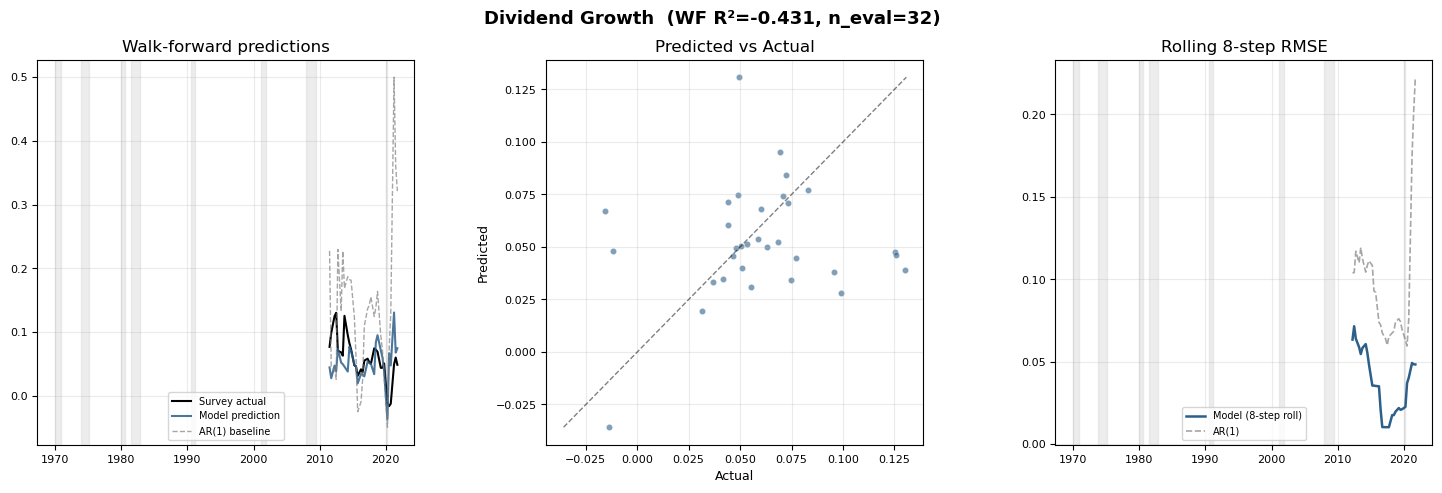

Saved diagnostics_dividend_growth.png


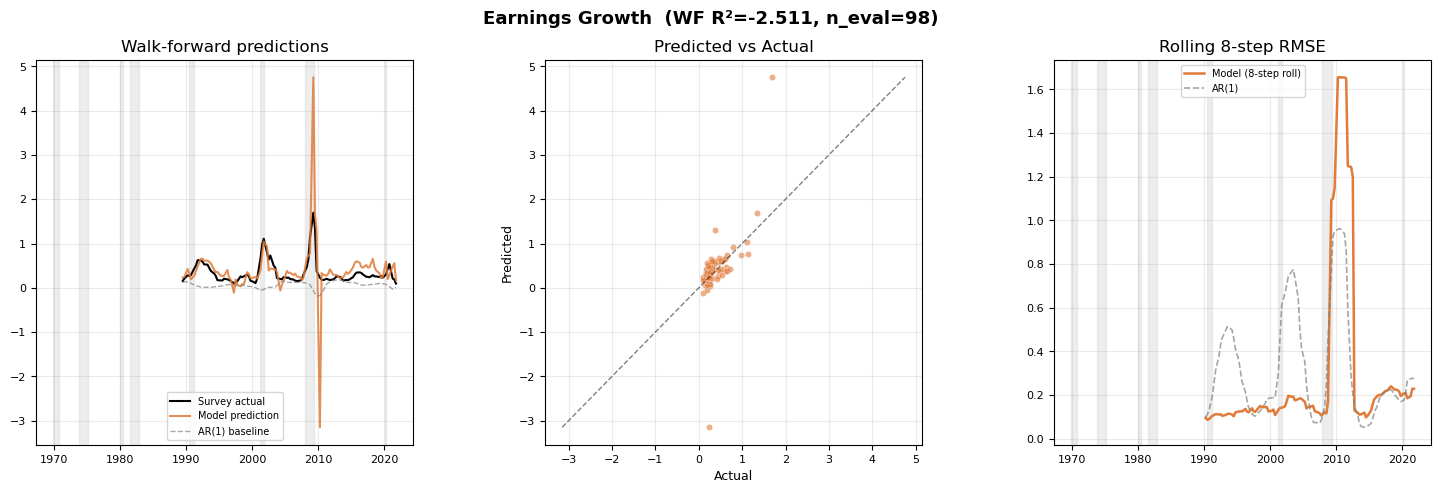

Saved diagnostics_earnings_growth.png


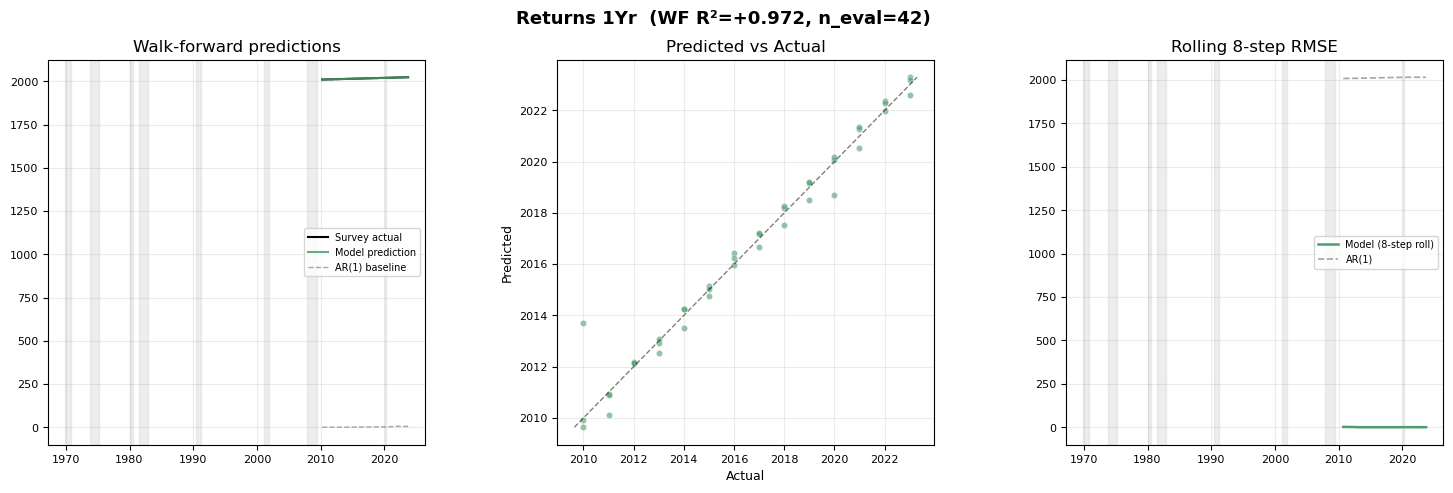

Saved diagnostics_returns_1yr.png


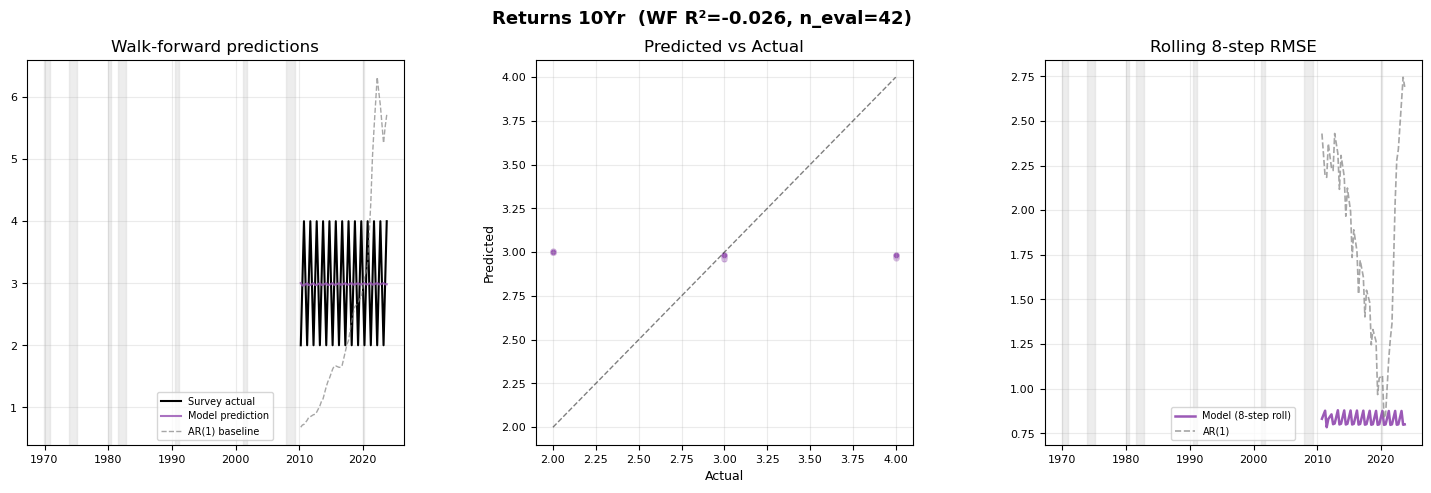

Saved diagnostics_returns_10yr.png


In [15]:
# NBER recession dates (approximate quarterly start/end for shading)
RECESSIONS = [
    ("1969-12", "1970-11"), ("1973-11", "1975-03"), ("1980-01", "1980-07"),
    ("1981-07", "1982-11"), ("1990-07", "1991-03"), ("2001-03", "2001-11"),
    ("2007-12", "2009-06"), ("2020-02", "2020-04"),
]

COLORS = {
    "dividend_growth": "#2c5f8a",
    "earnings_growth": "#e07b39",
    "returns_1yr":     "#4a9e6b",
    "returns_10yr":    "#9b59b6",
}

ROLL_WINDOW = 8

for series_name, res in all_results.items():
    df   = res["results_df"]
    y    = df["actual"].values
    yhat = df["predicted"].values
    ar1  = df["ar1_pred"].values
    dates = pd.to_datetime(df["wave_date"])
    color = COLORS[series_name]

    fig = plt.figure(figsize=(18, 5))
    gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)
    fig.suptitle(f"{series_name.replace('_', ' ').title()}  "
                 f"(WF R²={res['wf_r2']:+.3f}, n_eval={res['n_eval']})",
                 fontsize=13, fontweight="bold")

    # Panel 1: Time series
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(dates, y,    color="black",  lw=1.5, label="Survey actual")
    ax1.plot(dates, yhat, color=color,    lw=1.5, label="Model prediction", alpha=0.85)
    ax1.plot(dates, ar1,  color="gray",   lw=1.0, ls="--", label="AR(1) baseline", alpha=0.7)
    for rec_start, rec_end in RECESSIONS:
        ax1.axvspan(pd.Timestamp(rec_start), pd.Timestamp(rec_end),
                    color="lightgray", alpha=0.4, zorder=0)
    ax1.set_title("Walk-forward predictions")
    ax1.legend(fontsize=7)
    ax1.grid(alpha=0.25)
    ax1.tick_params(labelsize=8)

    # Panel 2: Scatter
    ax2 = fig.add_subplot(gs[1])
    lo, hi = min(y.min(), yhat.min()), max(y.max(), yhat.max())
    ax2.scatter(y, yhat, color=color, alpha=0.6, s=20, edgecolors="white", lw=0.3)
    ax2.plot([lo, hi], [lo, hi], "k--", lw=1, alpha=0.5)
    ax2.set_xlabel("Actual", fontsize=9)
    ax2.set_ylabel("Predicted", fontsize=9)
    ax2.set_title("Predicted vs Actual")
    ax2.grid(alpha=0.25)
    ax2.tick_params(labelsize=8)

    # Panel 3: Rolling RMSE
    ax3 = fig.add_subplot(gs[2])
    model_sq  = (y - yhat) ** 2
    ar1_sq    = (y - ar1)  ** 2
    roll_mod  = pd.Series(model_sq).rolling(ROLL_WINDOW, min_periods=3).mean().pipe(np.sqrt)
    roll_ar1  = pd.Series(ar1_sq).rolling(ROLL_WINDOW,  min_periods=3).mean().pipe(np.sqrt)
    ax3.plot(dates, roll_mod,  color=color,  lw=1.8, label=f"Model ({ROLL_WINDOW}-step roll)")
    ax3.plot(dates, roll_ar1,  color="gray", lw=1.2, ls="--", label="AR(1)", alpha=0.7)
    for rec_start, rec_end in RECESSIONS:
        ax3.axvspan(pd.Timestamp(rec_start), pd.Timestamp(rec_end),
                    color="lightgray", alpha=0.4, zorder=0)
    ax3.set_title(f"Rolling {ROLL_WINDOW}-step RMSE")
    ax3.legend(fontsize=7)
    ax3.grid(alpha=0.25)
    ax3.tick_params(labelsize=8)

    plt.savefig(OUTPUT_DIR / f"diagnostics_{series_name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved diagnostics_{series_name}.png")


## 8. Feature Importance (Ridge Coefficients)

Ridge coefficients after standardisation give a read on which Shiller features
each series is loading on. This is the interpretability layer that replaces the
old FinBERT explainability cells.


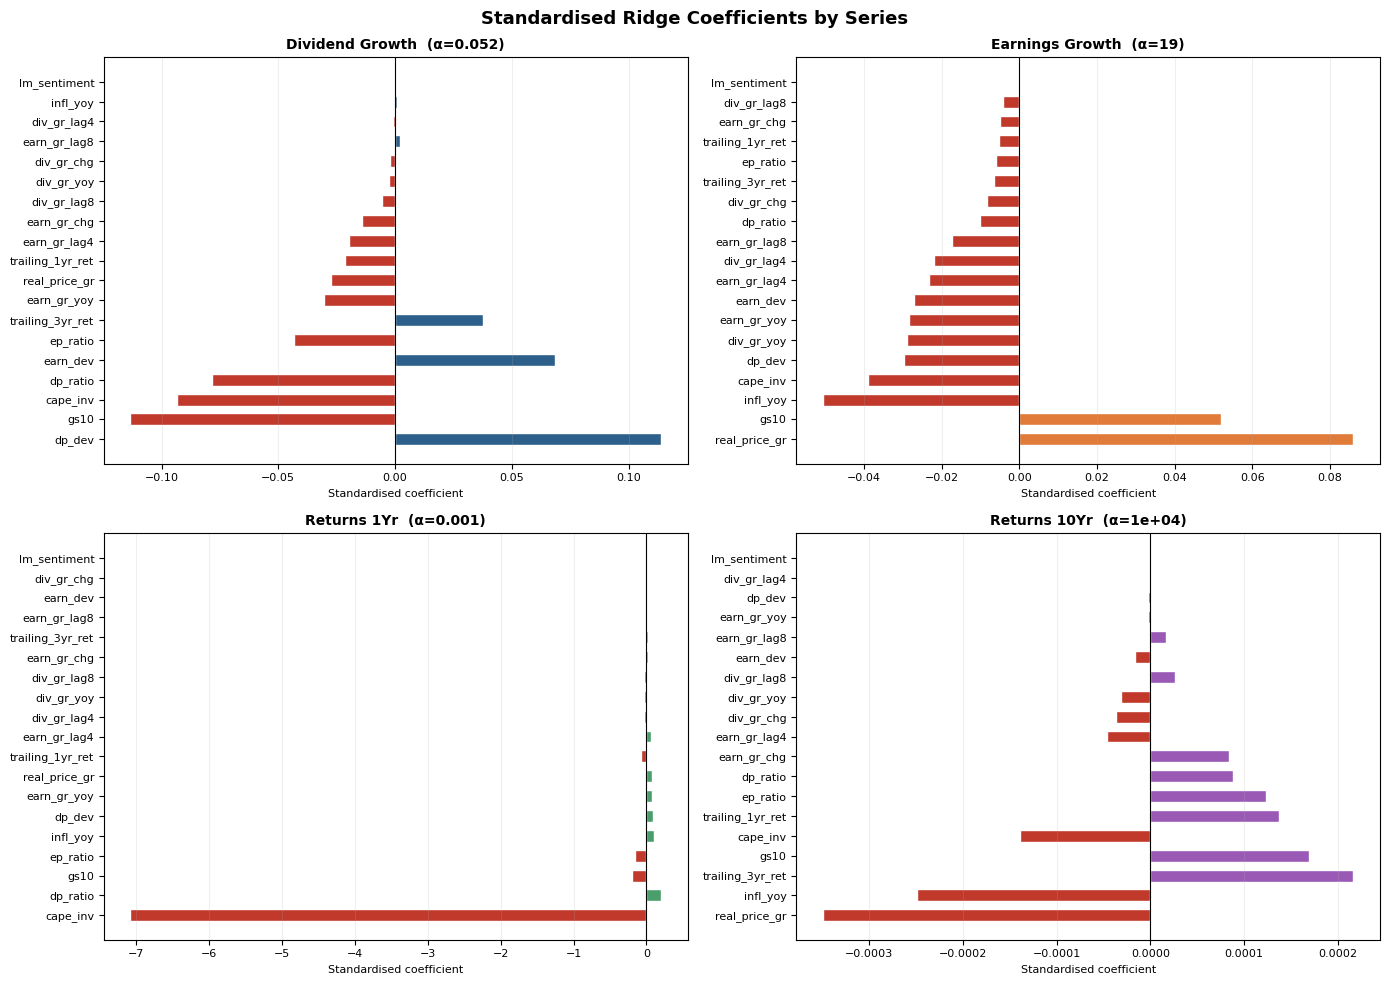

Saved feature_importance.png


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Standardised Ridge Coefficients by Series", fontsize=13, fontweight="bold")
axes = axes.flatten()

for ax, (series_name, model) in zip(axes, final_models.items()):
    ridge_step = model.named_steps["ridge"]
    coefs      = ridge_step.coef_
    feat_names = SHILLER_FEATURES

    order = np.argsort(np.abs(coefs))[::-1]
    colors_bar = [COLORS[series_name] if c > 0 else "#c0392b" for c in coefs[order]]

    ax.barh(np.array(feat_names)[order], coefs[order],
            color=colors_bar, edgecolor="white", height=0.6)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_title(series_name.replace("_", " ").title(), fontsize=10, fontweight="bold")
    ax.set_xlabel("Standardised coefficient", fontsize=8)
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.2, axis="x")
    alpha_val = ridge_step.alpha_
    ax.set_title(f"{series_name.replace('_',' ').title()}  (α={alpha_val:.2g})",
                 fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved feature_importance.png")


## 9. Save Final Models

Each model saved as `{series}/model_final.pkl` for use in the extrapolation
notebook. Includes the full sklearn Pipeline (scaler + ridge) and metadata.


In [17]:
for series_name, model in final_models.items():
    series_dir = OUTPUT_DIR / series_name
    series_dir.mkdir(parents=True, exist_ok=True)

    out = {
        "model":        model,
        "features":     SHILLER_FEATURES,
        "wf_r2":        all_results[series_name]["wf_r2"],
        "wf_rmse":      all_results[series_name]["wf_rmse"],
        "ar1_rmse":     all_results[series_name]["ar1_rmse"],
        "dir_acc":      all_results[series_name]["dir_acc"],
        "n_waves":      len(all_results[series_name]["y"]),
        "saved_at":     datetime.now().isoformat(),
    }
    with open(series_dir / "model_final.pkl", "wb") as f:
        pickle.dump(out, f)

    print(f"  Saved {series_name}/model_final.pkl  "
          f"(WF R²={out['wf_r2']:+.3f})")

print("\nAll models saved.")


  Saved dividend_growth/model_final.pkl  (WF R²=-0.431)
  Saved earnings_growth/model_final.pkl  (WF R²=-2.511)
  Saved returns_1yr/model_final.pkl  (WF R²=+0.972)
  Saved returns_10yr/model_final.pkl  (WF R²=-0.026)

All models saved.


## 10. Historical Extrapolation (1920 → Survey Start)

Apply the final fitted models to the pre-survey Shiller feature set to generate
synthetic survey-consistent expectations back to 1920.

**Important caveats documented inline:**
- The calibration relationship is assumed stable across regimes — this is tested
  but not guaranteed
- Great Depression era (1929–1933) and WWII era (1941–1945) are far from the
  calibration distribution; extrapolated values should be interpreted cautiously
- Dividend growth extrapolation has the weakest in-sample fit and widest
  uncertainty bounds; treat as indicative only


In [18]:
# Build monthly Shiller feature matrix for the pre-survey period
extrap_start = pd.Timestamp(EXTRAP_START)
extrap_end   = pd.Timestamp(EXTRAP_END)

shiller_extrap = shiller_df.loc[extrap_start:extrap_end].copy()
X_extrap = shiller_extrap[SHILLER_FEATURES].values

print(f"Extrapolation window: {shiller_extrap.index[0].date()} → {shiller_extrap.index[-1].date()}")
print(f"Monthly observations: {len(X_extrap)}")

# Flag out-of-distribution months using Mahalanobis distance
# Fit on calibration data (all survey waves combined)
from sklearn.covariance import EmpiricalCovariance

all_X_calib = np.vstack([data["X"] for data in aligned.values()])
cov = EmpiricalCovariance().fit(all_X_calib)
mahal_calib   = cov.mahalanobis(all_X_calib)
ood_threshold = np.percentile(mahal_calib, 97.5)   # 97.5th percentile of calibration distances
mahal_extrap  = cov.mahalanobis(X_extrap)
ood_flag      = mahal_extrap > ood_threshold

print(f"\nOOD threshold (97.5th pct of calibration): {ood_threshold:.2f}")
print(f"Out-of-distribution months in extrap window: {ood_flag.sum()} / {len(ood_flag)} "
      f"({ood_flag.mean():.1%})")


Extrapolation window: 1920-01-01 → 1970-01-01
Monthly observations: 704

OOD threshold (97.5th pct of calibration): 54.51
Out-of-distribution months in extrap window: 447 / 704 (63.5%)


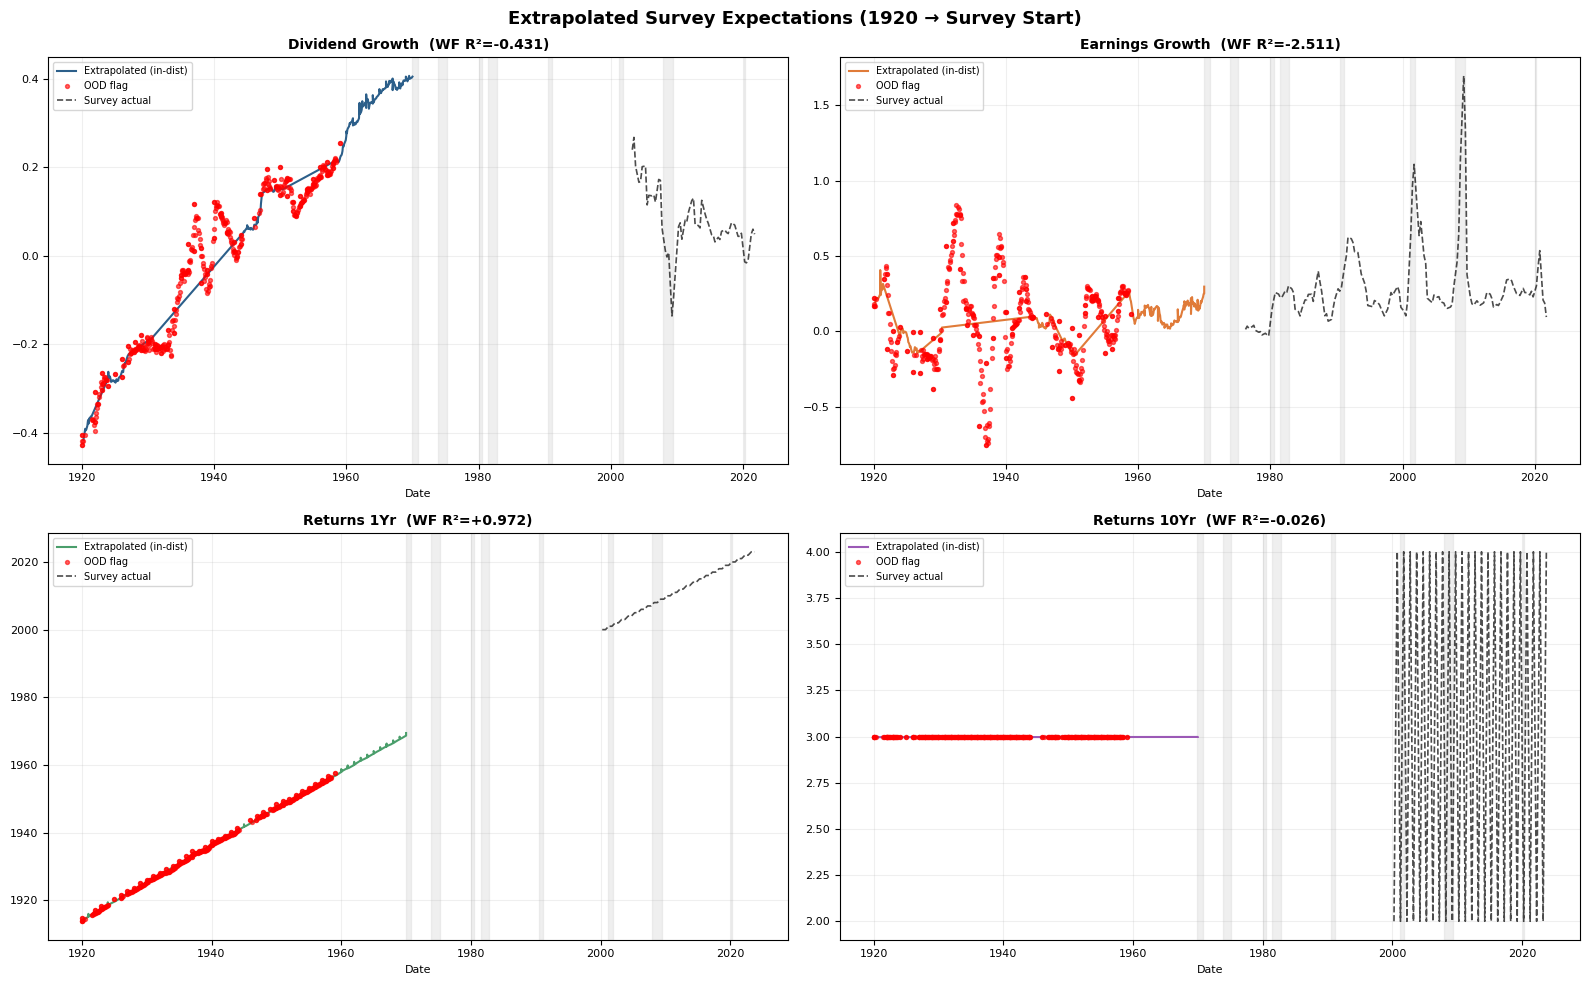

Saved extrapolated_expectations.png

All extrapolated series saved to CSV.


In [19]:
# Generate extrapolated expectations for each series
extrap_results = {}

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)
fig.suptitle("Extrapolated Survey Expectations (1920 → Survey Start)",
             fontsize=13, fontweight="bold")
axes = axes.flatten()

for ax, (series_name, model) in zip(axes, final_models.items()):
    yhat_extrap = model.predict(X_extrap)

    extrap_df = pd.DataFrame({
        "date":            shiller_extrap.index,
        "predicted":       yhat_extrap,
        "ood":             ood_flag,
    })
    extrap_results[series_name] = extrap_df

    # Save to CSV
    extrap_df.to_csv(OUTPUT_DIR / series_name / "extrapolated_expectations.csv", index=False)

    color = COLORS[series_name]

    # Plot extrapolated series
    in_dist  = extrap_df[~extrap_df["ood"]]
    out_dist = extrap_df[extrap_df["ood"]]
    ax.plot(in_dist["date"],  in_dist["predicted"],  color=color, lw=1.5,
            label="Extrapolated (in-dist)")
    ax.scatter(out_dist["date"], out_dist["predicted"], color="red", s=8,
               label="OOD flag", zorder=5, alpha=0.6)

    # Overlay survey period actuals for comparison
    survey_data = aligned[series_name]["waves"]
    ax.plot(survey_data["wave_date"], aligned[series_name]["y"],
            color="black", lw=1.2, ls="--", alpha=0.7, label="Survey actual")

    # Shade recessions
    for rec_start, rec_end in RECESSIONS:
        try:
            ax.axvspan(pd.Timestamp(rec_start), pd.Timestamp(rec_end),
                       color="lightgray", alpha=0.35, zorder=0)
        except Exception:
            pass

    wf_r2 = all_results[series_name]["wf_r2"]
    ax.set_title(f"{series_name.replace('_', ' ').title()}  (WF R²={wf_r2:+.3f})",
                 fontsize=10, fontweight="bold")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.2)
    ax.tick_params(labelsize=8)
    ax.set_xlabel("Date", fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "extrapolated_expectations.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved extrapolated_expectations.png")
print("\nAll extrapolated series saved to CSV.")


## 11. Robustness: Subsample Stability

Split the survey calibration period into early and late halves. Re-estimate
the model on each half and compare coefficients. If the Ridge coefficients are
stable across halves, the extrapolation relationship is credible. Large
instability — particularly for dividend growth — should be flagged in the paper.


In [20]:
print("Subsample stability check")
print("─" * 70)

for series_name, data in aligned.items():
    X, y = data["X"], data["y"]
    n    = len(y)
    mid  = n // 2

    m_early = make_model(series_name)
    m_late  = make_model(series_name)
    m_early.fit(X[:mid], y[:mid])
    m_late.fit(X[mid:],  y[mid:])

    coef_early = m_early.named_steps["ridge"].coef_
    coef_late  = m_late.named_steps["ridge"].coef_

    # Correlation between early and late coefficients
    coef_corr = np.corrcoef(coef_early, coef_late)[0, 1]
    print(f"  {series_name:22s}: coef correlation early/late = {coef_corr:+.3f}  "
          f"(n_early={mid}, n_late={n-mid})")

print()
print("Interpretation:")
print("  |r| > 0.9 → stable relationship, extrapolation credible")
print("  |r| < 0.7 → structural instability, extrapolation uncertain")
print("  Dividend growth typically shows lowest stability given short series")


Subsample stability check
──────────────────────────────────────────────────────────────────────
  dividend_growth       : coef correlation early/late = +0.654  (n_early=28, n_late=29)
  earnings_growth       : coef correlation early/late = -0.011  (n_early=69, n_late=69)
  returns_1yr           : coef correlation early/late = +0.668  (n_early=36, n_late=36)
  returns_10yr          : coef correlation early/late = -0.245  (n_early=36, n_late=36)

Interpretation:
  |r| > 0.9 → stable relationship, extrapolation credible
  |r| < 0.7 → structural instability, extrapolation uncertain
  Dividend growth typically shows lowest stability given short series


## 12. Summary and Next Steps

### Results summary
Run this cell after the pipeline completes to print a final summary for the paper.


## DIAGNOSTIC — Scale and Distribution Check

Run this immediately when walk-forward R² is unexpectedly negative.
Checks for the most common failure modes:
1. Unit mismatch between survey (% pts) and Shiller features (decimals)
2. Survey series loading incorrectly
3. Walk-forward predictions wildly out of range


In [ ]:
print("=" * 70)
print("SCALE AND DISTRIBUTION DIAGNOSTIC")
print("=" * 70)

# ── 1. Survey series ranges ───────────────────────────────────────────────────
print("\n1. Survey series — median_forecast ranges:")
print(f"   {'Series':22s} {'Min':>10} {'Max':>10} {'Mean':>10} {'Std':>10} {'N':>6}")
print("   " + "-" * 62)
for name, data in aligned.items():
    y = data["y"]
    print(f"   {name:22s} {y.min():>10.4f} {y.max():>10.4f} "
          f"{y.mean():>10.4f} {y.std():>10.4f} {len(y):>6d}")

# ── 2. Key Shiller feature ranges ─────────────────────────────────────────────
print("\n2. Key Shiller features — are earn/div growth in decimals or pct pts?")
print(f"   {'Feature':22s} {'Min':>10} {'Max':>10} {'Mean':>10}")
print("   " + "-" * 46)
for feat in ["earn_gr_yoy", "div_gr_yoy", "trailing_1yr_ret", "dp_ratio", "ep_ratio"]:
    if feat in shiller_df.columns:
        col = shiller_df[feat]
        print(f"   {feat:22s} {col.min():>10.4f} {col.max():>10.4f} {col.mean():>10.4f}")

print("\n   >>> If earn_gr_yoy ~ 0.05 but survey ~ 5.0, there is a 100x scale mismatch")
print("   >>> Fix: multiply Shiller growth features by 100 in load_shiller()")

# ── 3. Walk-forward prediction ranges ─────────────────────────────────────────
print("\n3. Walk-forward prediction ranges vs actuals:")
print(f"   {'Series':22s} {'Pred min':>10} {'Pred max':>10} {'Act min':>10} {'Act max':>10}")
print("   " + "-" * 54)
for name, res in all_results.items():
    df = res["results_df"]
    print(f"   {name:22s} {df['predicted'].min():>10.4f} {df['predicted'].max():>10.4f} "
          f"{df['actual'].min():>10.4f} {df['actual'].max():>10.4f}")

print("\n   >>> Pred and actual ranges should be in the same ballpark")
print("   >>> If preds are ~0.05 and actuals ~5.0 — scale mismatch confirmed")

# ── 4. First few walk-forward steps ───────────────────────────────────────────
print("\n4. First 5 walk-forward steps per series:")
for name, res in all_results.items():
    df = res["results_df"].head(5)
    print(f"\n   {name}:")
    print(f"   {'Date':12s} {'Actual':>10} {'Predicted':>12} {'AR(1)':>10} {'Error':>10}")
    for _, row in df.iterrows():
        err = row['predicted'] - row['actual']
        print(f"   {str(row['wave_date'])[:10]:12s} {row['actual']:>10.4f} "
              f"{row['predicted']:>12.4f} {row['ar1_pred']:>10.4f} {err:>10.4f}")


In [ ]:
print("=" * 70)
print("FINAL SUMMARY — Macro-Based Survey Expectations Pipeline")
print("=" * 70)
print()
print(f"{'Series':22s} {'WF R²':>8} {'vs AR(1)':>10} {'DirAcc':>8} {'n_eval':>7}")
print("-" * 60)
for name, res in all_results.items():
    delta = res["wf_rmse"] - res["ar1_rmse"]
    print(f"{name:22s} {res['wf_r2']:>+8.3f} {delta:>+10.4f} "
          f"{res['dir_acc']:>7.1%} {res['n_eval']:>7d}")

print()
print("Output files:")
for series_name in final_models:
    print(f"  {OUTPUT_DIR}/{series_name}/model_final.pkl")
    print(f"  {OUTPUT_DIR}/{series_name}/extrapolated_expectations.csv")
print(f"  {OUTPUT_DIR}/diagnostics_*.png")
print(f"  {OUTPUT_DIR}/feature_importance.png")
print(f"  {OUTPUT_DIR}/extrapolated_expectations.png")
print()
print("Next steps:")
print("  1. Review OOD flags in extrapolation — Depression era will flag heavily")
print("  2. Add trailing_3yr_ret to returns models if 1yr dominates importance")
print("  3. For Campbell-Shiller decomp: load extrapolated_expectations.csv")
print("     and merge with Shiller realized returns/dividends on date key")
